# ðŸ” Multi-Source Fraud Investigation with Agentic Retrieval

This notebook demonstrates two approaches to building a **multi-source AI fraud investigation system**:

1. **Foundry IQ Agentic Retrieval** â€” Create a Knowledge Base with answer synthesis that intelligently routes queries across multiple knowledge sources and generates grounded answers.
2. **AzureAISearchTool Agent** â€” Wire the same indexes into a Prompt Agent using `AzureAISearchTool` (the pattern used in `scripts/deploy_agents.py`).

## What You'll Build

**3 specialized search indexes** feeding both a Knowledge Base and a Prompt Agent:

| # | Index | Content |
|---|-------|---------|
| 1ï¸âƒ£ | **fraud-patterns-index** | Historical fraud patterns, red flags, detection strategies |
| 2ï¸âƒ£ | **regulatory-compliance-index** | FSI regulations, AML/KYC requirements, reporting guidelines |
| 3ï¸âƒ£ | **investigation-procedures-index** | Case handling protocols, evidence collection, escalation workflows |

### Architecture

```
â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”
â”‚                    FOUNDRY IQ                                â”‚
â”‚        (Unified Knowledge Layer for Agents)                  â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚                                                              â”‚
â”‚  â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”  â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”  â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”      â”‚
â”‚  â”‚ Fraud        â”‚  â”‚ Regulatory   â”‚  â”‚ Investigationâ”‚      â”‚
â”‚  â”‚ Patterns     â”‚  â”‚ Compliance   â”‚  â”‚ Procedures   â”‚      â”‚
â”‚  â”‚ (Index 1)    â”‚  â”‚ (Index 2)    â”‚  â”‚ (Index 3)    â”‚      â”‚
â”‚  â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜  â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜  â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜      â”‚
â”‚         â”‚                 â”‚                 â”‚               â”‚
â”‚         â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜               â”‚
â”‚                           â–¼                                  â”‚
â”‚              â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”                        â”‚
â”‚              â”‚   Knowledge Base    â”‚                        â”‚
â”‚              â”‚ (Intelligent Router)â”‚                        â”‚
â”‚              â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜                        â”‚
â”‚                           â”‚                                  â”‚
â”‚                           â–¼                                  â”‚
â”‚              â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”                        â”‚
â”‚              â”‚   Fraud Analyst     â”‚                        â”‚
â”‚              â”‚      Agent          â”‚                        â”‚
â”‚              â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜                        â”‚
â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜
```

### Steps

1. Install packages
2. Connect to Azure
3. Generate synthetic fraud data
4. Create search indexes
5. Generate embeddings and upload documents
6. Create knowledge sources
7. Create knowledge base (agentic retrieval with answer synthesis)
8. Query knowledge base directly
9. Create agent with `AzureAISearchTool`
10. Test agent with multi-source queries
11. Cleanup

### References
- [Foundry IQ: Unlocking ubiquitous knowledge for agents](https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/foundry-iq-unlocking-ubiquitous-knowledge-for-agents/4470812)
- [Foundry IQ: Boost response relevance by 36% with agentic retrieval](https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/foundry-iq-boost-response-relevance-by-36-with-agentic-retrieval/4470720)
- [Create a knowledge base in Azure AI Search](https://learn.microsoft.com/en-us/azure/search/agentic-retrieval-how-to-create-knowledge-base)
- [AzureAISearchTool docs](https://learn.microsoft.com/en-us/azure/foundry/agents/how-to/tools/azure-ai-search)


---

## ðŸ“¦ Step 1: Install Required Packages

The required packages should already be installed via the `requirements.txt` file at the project root:

```bash
pip install -r requirements.txt
```

If packages are not installed, uncomment and run the cell below.

In [1]:
# Packages should be installed via requirements.txt at project root
# If not installed, uncomment the line below and run this cell:

# %pip install azure-search-documents>=11.7.0b2 azure-ai-projects>=2.0.0b1 azure-identity openai python-dotenv --quiet

print("âœ… Packages ready (installed via requirements.txt)")

âœ… Packages ready (installed via requirements.txt)


---

## ðŸ” Step 2: Load Configuration and Connect to Azure

Load environment variables and establish connections to Azure services.

In [2]:
import os
from dotenv import load_dotenv
from azure.identity import AzureCliCredential, get_bearer_token_provider
from azure.core.credentials import AzureKeyCredential
from azure.ai.projects import AIProjectClient
from azure.ai.projects.models import ConnectionType
from azure.search.documents.indexes import SearchIndexClient
from openai import AzureOpenAI

# Load environment variables
load_dotenv('.env')

# Configuration â€” only two env vars needed
project_endpoint = os.environ["FOUNDRY_PROJECT_ENDPOINT"]
model_deployment = os.getenv("FOUNDRY_MODEL", "gpt-4o")
embedding_deployment = "text-embedding-ada-002"  # deployed on this resource

print("âœ… Environment loaded")
print(f"\nðŸ“ Configuration:")
print(f"   â€¢ Project Endpoint: {project_endpoint[:50]}...")
print(f"   â€¢ Model: {model_deployment}")
print(f"   â€¢ Embedding: {embedding_deployment}")

# Create credential and clients
credential = AzureCliCredential(process_timeout=30)
print("\nðŸ” Using AzureCliCredential for authentication")

# Initialize project client
project_client = AIProjectClient(endpoint=project_endpoint, credential=credential)
openai_client = project_client.get_openai_client()

# Derive search endpoint and credentials from the default AI Search connection
search_conn = project_client.connections.get_default(
    connection_type=ConnectionType.AZURE_AI_SEARCH, include_credentials=True
)
search_endpoint = search_conn.target

# Use API key from connection if available (matches lab 5 pattern)
if search_conn.credentials.get('type') == 'AAD':
    print("ðŸ” Using Azure AD authentication for AI Search")
    search_credential = credential
else:
    search_credential = AzureKeyCredential(search_conn.credentials['key'])
    print("ðŸ”‘ Using API Key authentication for AI Search")

index_client = SearchIndexClient(endpoint=search_endpoint, credential=search_credential)

# Derive project resource ID from connection ID
# Connection ID format: /subscriptions/.../projects/.../connections/<name>
project_resource_id = search_conn.id.rsplit("/connections/", 1)[0]

# Derive the OpenAI base endpoint from the Foundry project endpoint
# FOUNDRY_PROJECT_ENDPOINT: https://<account>.services.ai.azure.com/api/projects/<project>
azure_openai_endpoint = project_endpoint.split("/api/projects/")[0]

# Azure OpenAI client for embeddings
token_provider = get_bearer_token_provider(credential, "https://cognitiveservices.azure.com/.default")
aoai_client = AzureOpenAI(
    api_version="2024-02-01",
    azure_endpoint=azure_openai_endpoint,
    azure_ad_token_provider=token_provider
)

print(f"\n   â€¢ Search Endpoint: {search_endpoint}")
print(f"   â€¢ OpenAI Endpoint: {azure_openai_endpoint}")
print(f"   â€¢ Project Resource ID: ...{project_resource_id[-60:]}")
print("âœ… All clients initialized successfully")

âœ… Environment loaded

ðŸ“ Configuration:
   â€¢ Project Endpoint: https://alliander-foundry-uvrqgq.services.ai.azure...
   â€¢ Model: gpt-4o
   â€¢ Embedding: text-embedding-ada-002

ðŸ” Using AzureCliCredential for authentication
ðŸ”‘ Using API Key authentication for AI Search

   â€¢ Search Endpoint: https://alliander-search-uvrqgq.search.windows.net
   â€¢ OpenAI Endpoint: https://alliander-foundry-uvrqgq.services.ai.azure.com
   â€¢ Project Resource ID: ...accounts/alliander-foundry-uvrqgq/projects/alliander-project
âœ… All clients initialized successfully


---

## ðŸ“Š Step 3: Generate Synthetic Fraud Investigation Data

Create realistic unstructured text data for three knowledge domains. This data is generated in-memory - no external files needed!

In [3]:
# ============================================================================
# KNOWLEDGE SOURCE 1: Fraud Pattern Intelligence
# Unstructured narratives about fraud patterns, red flags, and detection strategies
# ============================================================================

fraud_patterns_data = [
    {
        "id": "fp-001",
        "title": "Synthetic Identity Fraud Patterns",
        "content": """Synthetic identity fraud is one of the fastest-growing types of financial crime. Fraudsters create fake identities by combining real and fabricated information - often using a legitimate Social Security Number (frequently from children, elderly, or deceased individuals) with fictitious names and addresses. Key red flags include: credit files with limited history showing sudden high-value applications, addresses that are PO boxes or commercial mail receiving agencies, phone numbers that are VoIP or recently activated, and employment information that cannot be verified. Detection strategies should focus on cross-referencing identity elements across multiple data sources, analyzing the velocity of credit applications, and using machine learning models trained on known synthetic patterns. Financial institutions report that synthetic fraud accounts often remain dormant for 12-24 months before being 'busted out' with maximum credit utilization."""
    },
    {
        "id": "fp-002", 
        "title": "Account Takeover Fraud Indicators",
        "content": """Account takeover (ATO) fraud occurs when criminals gain unauthorized access to customer accounts. Common indicators include: login attempts from new devices or geographic locations inconsistent with customer history, rapid changes to account contact information (email, phone, address) followed by high-value transactions, password reset requests from unfamiliar IP addresses, multiple failed authentication attempts before successful login, and session anomalies like unusual browsing patterns. Sophisticated ATO attacks often begin with phishing or credential stuffing. Behavioral biometrics can detect when account activity deviates from established patterns - such as typing speed, mouse movements, and navigation habits. Real-time monitoring should flag accounts where contact information changes are immediately followed by wire transfers or beneficiary additions."""
    },
    {
        "id": "fp-003",
        "title": "Money Mule Network Detection",
        "content": """Money mule networks facilitate the movement of illicit funds through seemingly legitimate bank accounts. Characteristics of mule accounts include: recently opened accounts with minimal activity followed by sudden large deposits, rapid transfers out within 24-48 hours of receiving funds, deposits that match common fraud amounts ($9,900 to avoid reporting thresholds), multiple accounts receiving funds from the same source, and account holders who are students, recently unemployed, or new to the country. Network analysis can reveal connections between mule accounts through shared attributes like device fingerprints, IP addresses, or communication patterns. Banks should implement velocity rules monitoring the frequency and amounts of incoming/outgoing transfers, particularly for accounts less than 90 days old."""
    },
    {
        "id": "fp-004",
        "title": "Business Email Compromise Patterns",
        "content": """Business Email Compromise (BEC) fraud involves impersonating executives or vendors to redirect payments. Red flags include: emails from lookalike domains with subtle misspellings, requests to change payment details for existing vendors, urgency language and secrecy requests in communications, wire transfer requests outside normal business processes, and payment routing to personal accounts or unfamiliar banks. Fraudsters often conduct reconnaissance for weeks before striking, timing attacks during executive travel or during busy periods. Prevention requires out-of-band verification for all payment changes using pre-established phone numbers, not contact information provided in the suspicious email. Financial controls should require dual authorization for payment changes and new vendor setups."""
    },
    {
        "id": "fp-005",
        "title": "First-Party Fraud Schemes",
        "content": """First-party fraud occurs when individuals misrepresent their own information for financial gain. Common schemes include: application fraud with inflated income or employment, friendly fraud where legitimate purchases are disputed as unauthorized, bust-out schemes where credit is maximized then abandoned, and insurance fraud through staged accidents or exaggerated claims. Indicators include inconsistencies between stated income and address demographics, multiple applications within short timeframes, disputes filed on high-value purchases just before return windows expire, and claims patterns inconsistent with policy history. Detection requires comparing applicant statements against third-party data sources and analyzing behavioral patterns across the customer lifecycle."""
    },
    {
        "id": "fp-006",
        "title": "Check and ACH Fraud Detection",
        "content": """Check and ACH fraud remain prevalent despite digital payment growth. Check fraud indicators include: checks deposited via mobile capture with edited images, altered payee names or amounts, counterfeit checks using real account numbers, and kiting schemes between multiple accounts. ACH fraud signs include: unauthorized debits from compromised account credentials, credits followed by rapid withdrawals before returns, and recurring debits from unfamiliar originators. Positive pay systems that match presented checks against issued check files can prevent most check fraud. ACH fraud prevention requires monitoring for first-time ACH relationships, high-value single transactions, and transactions to accounts with recent ownership changes."""
    },
    {
        "id": "fp-007",
        "title": "Elder Financial Exploitation Patterns",
        "content": """Elder financial exploitation is a growing concern in financial services. Warning signs include: sudden changes in banking patterns for long-term customers over 65, new authorized users or powers of attorney added to accounts, large withdrawals inconsistent with customer history, wire transfers to unfamiliar recipients, and signs of customer confusion during transactions. Exploitation often involves family members, caregivers, or romance scam perpetrators. Staff training should emphasize recognizing signs of undue influence, including customers appearing coached during transactions, reluctance to speak without a companion present, and fear or anxiety when discussing account activity. Suspicious activity should be reported to Adult Protective Services and may require filing SARs."""
    },
    {
        "id": "fp-008",
        "title": "Cryptocurrency-Related Fraud Schemes",
        "content": """Cryptocurrency enables new fraud vectors requiring specialized detection. Common schemes include: investment scams promising unrealistic returns, pig butchering scams building relationships before requesting crypto investments, romance scams demanding crypto payments, and fake exchange platforms that steal deposits. Red flags in traditional banking include: frequent purchases at crypto exchanges inconsistent with customer profile, rapid account funding followed by crypto purchases and depletion, customers describing 'investment advisors' met online, and requests to send wire transfers to overseas exchanges. Financial institutions should provide customer education about crypto scams and implement friction for high-risk transactions to crypto-related merchants."""
    }
]

print(f"ðŸ“Š Generated {len(fraud_patterns_data)} Fraud Pattern Intelligence documents")
for doc in fraud_patterns_data[:3]:
    print(f"   â€¢ {doc['title']}")
print(f"   ... and {len(fraud_patterns_data) - 3} more")

# ============================================================================
# KNOWLEDGE SOURCE 2: Regulatory Compliance Guidelines
# FSI regulations, AML/KYC requirements, and reporting obligations
# ============================================================================

regulatory_compliance_data = [
    {
        "id": "rc-001",
        "title": "Bank Secrecy Act Requirements",
        "content": """The Bank Secrecy Act (BSA) requires financial institutions to maintain robust anti-money laundering programs. Key requirements include: establishing written AML policies and procedures approved by the board, designating a qualified BSA/AML compliance officer, implementing a customer due diligence (CDD) program, providing ongoing employee training, and conducting independent testing of the AML program at least annually. Institutions must also establish risk-based procedures for conducting ongoing customer due diligence including understanding the nature and purpose of customer relationships to develop customer risk profiles, and conducting ongoing monitoring to identify and report suspicious transactions. Failure to maintain adequate AML programs can result in civil money penalties, enforcement actions, and reputational damage."""
    },
    {
        "id": "rc-002",
        "title": "Suspicious Activity Report Filing Guidelines",
        "content": """Financial institutions must file Suspicious Activity Reports (SARs) for transactions that may involve money laundering, BSA violations, or other suspicious activities. Filing thresholds vary by institution type but generally require reporting transactions of $5,000 or more for banks and $2,000 for money services businesses when the institution knows, suspects, or has reason to suspect the transaction: involves funds from illegal activity, is designed to evade reporting requirements, lacks a lawful purpose, or involves use of the institution to facilitate criminal activity. SARs must be filed within 30 days of initial detection (60 days if no suspect is identified), must not be disclosed to subjects, and must be retained for five years. Quality SAR narratives should answer who, what, when, where, why, and how, including all relevant transaction details and supporting documentation."""
    },
    {
        "id": "rc-003",
        "title": "Customer Identification Program Standards",
        "content": """The Customer Identification Program (CIP) rule requires verification of customer identity at account opening. For individuals, institutions must collect name, date of birth, address, and identification number (SSN for US persons or passport/alien ID for non-US persons). For businesses, required information includes legal name, principal place of business address, employer identification number, and documents showing legal existence. Verification must occur within a reasonable time and may use documentary methods (government ID, business documents) or non-documentary methods (credit reports, public databases). Institutions must maintain records of identification information for five years after account closure and must check names against government lists of known terrorists. Risk-based procedures should require enhanced verification for higher-risk customers such as those in high-risk jurisdictions or industries."""
    },
    {
        "id": "rc-004",
        "title": "Enhanced Due Diligence Requirements",
        "content": """Enhanced Due Diligence (EDD) must be applied to higher-risk customers including: politically exposed persons (PEPs) and their family members, customers from high-risk jurisdictions identified by FATF, correspondent banking relationships with foreign financial institutions, private banking customers, and any relationship where standard due diligence indicates elevated risk. EDD procedures should include: senior management approval for establishing relationships, reasonable measures to establish source of wealth and source of funds, enhanced ongoing monitoring with more frequent reviews, and additional documentation requirements. For correspondent banking, EDD must assess the respondent bank's AML controls, services offered, and any nested relationships. PEP screening should cover both domestic and foreign PEPs, with ongoing monitoring for customers who become PEPs after account opening."""
    },
    {
        "id": "rc-005",
        "title": "Currency Transaction Reporting Rules",
        "content": """Financial institutions must file Currency Transaction Reports (CTRs) for cash transactions exceeding $10,000 in a single business day. This includes deposits, withdrawals, currency exchanges, and other payments made in currency. Multiple transactions must be aggregated if the institution has knowledge that transactions are conducted by or on behalf of the same person. CTRs must be filed within 15 calendar days following the transaction date. Structuring - conducting transactions to evade CTR requirements - is a federal crime even if the underlying funds are legitimate. Institutions should monitor for structuring patterns including: transactions just below $10,000, multiple branch transactions on the same day, round-dollar cash transactions, and customers who appear nervous about identification requirements during cash transactions."""
    },
    {
        "id": "rc-006",
        "title": "OFAC Sanctions Compliance",
        "content": """The Office of Foreign Assets Control (OFAC) administers economic sanctions that prohibit transactions with sanctioned countries, entities, and individuals. Financial institutions must screen customers, counterparties, and transactions against OFAC lists including the Specially Designated Nationals (SDN) list. Screening must occur at account opening, when customer information changes, when OFAC lists are updated, and for all incoming/outgoing wire transfers. Potential matches require review to confirm or rule out true matches before processing transactions. Blocked transactions must be placed in an interest-bearing account and reported to OFAC within 10 business days. Rejected transactions must also be reported. Institutions should implement a risk-based approach to sanctions compliance considering geographic exposure, customer types, and products offered. Voluntary self-disclosure of violations may result in reduced penalties."""
    },
    {
        "id": "rc-007",
        "title": "Consumer Financial Protection Requirements",
        "content": """Consumer protection regulations require fair treatment of customers in fraud investigations. Under Regulation E, consumers must report unauthorized electronic fund transfers within 60 days to limit liability, and institutions must investigate and resolve claims within 10 business days (20 days for new accounts). Provisional credit must be provided if investigations extend beyond these timeframes. For credit card fraud under Regulation Z, consumer liability is limited to $50 for unauthorized transactions reported before the card is used. Fair lending requirements prohibit discrimination in fraud investigation outcomes based on protected characteristics. Privacy regulations require protecting customer information collected during investigations. Documentation of investigation processes and outcomes must be maintained for compliance examination and potential litigation."""
    },
    {
        "id": "rc-008",
        "title": "Third-Party Risk Management for Fraud Prevention",
        "content": """Regulatory guidance requires oversight of third-party vendors used in fraud detection and prevention. Due diligence before engagement should assess the vendor's financial condition, security practices, regulatory compliance, and relevant expertise. Contracts should address data protection requirements, performance standards, audit rights, and subcontracting limitations. Ongoing monitoring should include regular performance reviews, security assessments, and verification of continued compliance. For critical vendors, institutions should maintain contingency plans addressing vendor failure or relationship termination. AI and machine learning models from vendors must be understood sufficiently to explain adverse decisions to customers and regulators. Model risk management requirements apply to third-party fraud detection models with periodic validation and documentation of model performance."""
    }
]

print(f"\nðŸ“Š Generated {len(regulatory_compliance_data)} Regulatory Compliance documents")
for doc in regulatory_compliance_data[:3]:
    print(f"   â€¢ {doc['title']}")
print(f"   ... and {len(regulatory_compliance_data) - 3} more")

# ============================================================================
# KNOWLEDGE SOURCE 3: Investigation Procedures
# Case handling protocols, evidence collection, and escalation workflows
# ============================================================================

investigation_procedures_data = [
    {
        "id": "ip-001",
        "title": "Initial Alert Triage Process",
        "content": """When a fraud alert is generated, analysts must complete initial triage within 4 hours for high-severity alerts and 24 hours for standard alerts. Triage steps include: reviewing alert details and triggering transaction(s), examining customer profile and account history, checking for related alerts or previous investigations, and documenting initial assessment in the case management system. Disposition options are: promote to investigation (with priority assignment), disposition as false positive (with documented rationale), or escalate for immediate action (for ongoing fraud or imminent loss). False positive documentation must explain why the activity is legitimate, referencing specific customer information or transaction patterns. All triage decisions require supervisor review for alerts above $25,000 or involving VIP customers."""
    },
    {
        "id": "ip-002",
        "title": "Account Freeze and Hold Procedures",
        "content": """Account freezes may be implemented when fraud is suspected to prevent further losses. Full freezes block all account activity and require compliance officer approval for accounts with balances exceeding $100,000. Partial holds restrict specific transaction types or channels while allowing essential activity. Customer notification requirements depend on freeze type and suspicion level - law enforcement holds cannot be disclosed. Documentation must include: justification for the freeze, approving authority, notification status, and planned review date. Freezes must be reviewed every 48 hours and lifted or renewed with documented justification. Excessive freeze duration without investigation progress may result in customer harm and regulatory criticism. Alternative controls like enhanced monitoring or reduced limits should be considered when full freezes cause disproportionate impact."""
    },
    {
        "id": "ip-003",
        "title": "Customer Contact Interview Techniques",
        "content": """Customer interviews are essential for distinguishing fraud from authorized activity. Before contact, review full account history, previous contacts, and alert details. Begin with open-ended questions about general account usage before addressing specific transactions. Key areas to cover: transaction purpose and counterparty relationships, device and location at time of transaction, whether credentials have been shared or compromised, and any unusual contacts or communications received. Document customer demeanor and consistency of responses. If fraud is confirmed, gather details about how compromise occurred for SAR narrative and pattern detection. If customer is suspected of first-party fraud, avoid accusatory language and focus on factual clarification. All interviews should be documented contemporaneously with quotes where relevant."""
    },
    {
        "id": "ip-004",
        "title": "Evidence Collection and Chain of Custody",
        "content": """Proper evidence handling is critical for potential law enforcement referrals and legal proceedings. Digital evidence must be preserved in original format with hash values documented. Screenshots should include timestamps, URL/system information, and analyst identification. Transaction records, communications, and system logs must be extracted through approved methods maintaining data integrity. Chain of custody documentation tracks evidence from collection through any transfers, storage, and ultimate disposition. Evidence storage must be secure with access limited to authorized personnel. Retention periods follow regulatory requirements (minimum 5 years for SAR-related materials) and legal hold requirements if litigation is anticipated. Never alter original evidence - create working copies for analysis and annotation."""
    },
    {
        "id": "ip-005",
        "title": "Loss Recovery and Chargeback Procedures",
        "content": """Loss recovery efforts should begin immediately upon confirmed fraud. For card transactions, initiate chargebacks within network timeframes (typically 120 days from transaction date). Wire recall requests must be sent within 24 hours of fraud discovery with specific information including beneficiary account, receiving bank, and fraud circumstances. ACH returns must be initiated within return timeframes (2 days for unauthorized entries). Document all recovery attempts and outcomes for reporting. Insurance claims for fraud losses require complete investigation files including loss calculations, recovery efforts, and root cause analysis. Subrogation opportunities exist when third parties contributed to the fraud. Recovery amounts should be tracked separately from gross loss figures for accurate fraud metrics."""
    },
    {
        "id": "ip-006",
        "title": "SAR Narrative Writing Standards",
        "content": """Effective SAR narratives must clearly communicate suspicious activity to FinCEN and law enforcement. Structure narratives to answer: who is conducting the suspicious activity, what instruments or mechanisms are being used, when did the activity occur (specific dates/timeframes), where did the activity take place (geographic and channel information), why is the activity suspicious (red flags and policy violations), and how was the suspicious activity committed. Include specific transaction details, amounts, dates, and counterparties. Describe the customer relationship and any relevant account history. Document investigation steps taken and findings. Avoid subjective characterizations or legal conclusions. Reference attachments containing supporting documentation. SARs for ongoing activity should be filed on a continuing basis (every 90 days) until activity ceases. Quality review by BSA staff should verify completeness and accuracy before filing."""
    },
    {
        "id": "ip-007",
        "title": "Law Enforcement Cooperation Protocols",
        "content": """Financial institutions must balance customer privacy with law enforcement cooperation. Subpoenas, summons, and search warrants require prompt response within specified timeframes - consult legal department for jurisdiction-specific requirements. Grand jury subpoenas have additional confidentiality obligations. Voluntary information sharing is permitted under the safe harbor for SAR-related information and through 314(b) registration for information sharing between financial institutions. 314(a) requests from FinCEN require searching records and reporting matches within 14 days. Direct law enforcement contacts outside formal process should be referred to designated liaison officers. Document all law enforcement contacts, requests, and responses. Testimony preparation requires legal coordination and review of investigation files. Never confirm or deny SAR filing to law enforcement or customers."""
    },
    {
        "id": "ip-008",
        "title": "Investigation Case Closure Standards",
        "content": """Case closure requires documented completion of all investigation steps and appropriate dispositions. Required elements for closure include: summary of initial alert and investigation scope, description of investigation activities and findings, conclusion regarding whether fraud occurred, quantification of actual or potential losses, documentation of SAR filing if applicable, description of recovery efforts and outcomes, recommendations for control improvements if relevant, and supervisor approval. Cases with unresolved elements require documented justification for closure with limitations noted. Closed cases must be retained according to record retention schedules (minimum 5 years for SAR-supporting documentation). Quality assurance reviews should sample closed cases for completeness and consistency. Reopen protocols exist for cases where new information emerges after closure."""
    }
]

print(f"\nðŸ“Š Generated {len(investigation_procedures_data)} Investigation Procedures documents")
for doc in investigation_procedures_data[:3]:
    print(f"   â€¢ {doc['title']}")
print(f"   ... and {len(investigation_procedures_data) - 3} more")

# Summary
total_docs = len(fraud_patterns_data) + len(regulatory_compliance_data) + len(investigation_procedures_data)
print(f"\n{'='*60}")
print(f"âœ… Total: {total_docs} unstructured documents generated")
print(f"{'='*60}")

ðŸ“Š Generated 8 Fraud Pattern Intelligence documents
   â€¢ Synthetic Identity Fraud Patterns
   â€¢ Account Takeover Fraud Indicators
   â€¢ Money Mule Network Detection
   ... and 5 more

ðŸ“Š Generated 8 Regulatory Compliance documents
   â€¢ Bank Secrecy Act Requirements
   â€¢ Suspicious Activity Report Filing Guidelines
   â€¢ Customer Identification Program Standards
   ... and 5 more

ðŸ“Š Generated 8 Investigation Procedures documents
   â€¢ Initial Alert Triage Process
   â€¢ Account Freeze and Hold Procedures
   â€¢ Customer Contact Interview Techniques
   ... and 5 more

âœ… Total: 24 unstructured documents generated


---

## ðŸ—ï¸ Step 4: Create Azure AI Search Indexes

Create three vector search indexes with semantic search enabled. Each index stores document embeddings (1536 dimensions from `text-embedding-ada-002`).


In [4]:
from azure.search.documents.indexes.models import (
    SearchIndex, SearchField, SearchFieldDataType, VectorSearch,
    HnswAlgorithmConfiguration, VectorSearchProfile, AzureOpenAIVectorizer,
    AzureOpenAIVectorizerParameters, SemanticSearch, SemanticConfiguration,
    SemanticPrioritizedFields, SemanticField
)
from azure.core.exceptions import ResourceNotFoundError
import time

# Define the 3 knowledge source configurations
knowledge_sources_config = {
    "fraud_patterns": {
        "index_name": "fraud-patterns-index",
        "ks_name": "fraud-patterns-ks",
        "description": "Fraud Pattern Intelligence - Historical fraud patterns, red flags, detection strategies, and behavioral indicators"
    },
    "regulatory_compliance": {
        "index_name": "regulatory-compliance-index",
        "ks_name": "regulatory-compliance-ks", 
        "description": "Regulatory Compliance - BSA/AML requirements, SAR filing guidelines, KYC procedures, OFAC sanctions"
    },
    "investigation_procedures": {
        "index_name": "investigation-procedures-index",
        "ks_name": "investigation-procedures-ks",
        "description": "Investigation Procedures - Case handling protocols, evidence collection, escalation workflows, closure standards"
    }
}

# Knowledge base name
knowledge_base_name = "fraud-investigation-kb"

# ============================================================================
# CLEANUP: Delete in correct order (KB -> KS -> Index)
# ============================================================================
print("ðŸ§¹ Cleaning up existing resources (if any)...")
print("="*60)

# Step 1: Delete knowledge base first (it references knowledge sources)
try:
    index_client.get_knowledge_base(knowledge_base_name)
    print(f"ðŸ—‘ï¸ Deleting knowledge base '{knowledge_base_name}'...")
    index_client.delete_knowledge_base(knowledge_base_name)
    time.sleep(2)
    print(f"   âœ… Knowledge base deleted")
except ResourceNotFoundError:
    print(f"   â„¹ï¸ Knowledge base '{knowledge_base_name}' not found (OK)")

# Step 2: Delete knowledge sources (they reference indexes)
for key, config in knowledge_sources_config.items():
    try:
        index_client.get_knowledge_source(config['ks_name'])
        print(f"ðŸ—‘ï¸ Deleting knowledge source '{config['ks_name']}'...")
        index_client.delete_knowledge_source(config['ks_name'])
        time.sleep(1)
        print(f"   âœ… Knowledge source deleted")
    except ResourceNotFoundError:
        print(f"   â„¹ï¸ Knowledge source '{config['ks_name']}' not found (OK)")

print(f"\n{'='*60}")
print("âœ… Cleanup complete - ready to create indexes")
print("="*60)

# ============================================================================
# CREATE INDEXES
# ============================================================================

def create_search_index(index_name):
    """Create a vector search index with hybrid search capabilities."""
    
    # Check if index exists â€” reuse if it can't be deleted
    try:
        index_client.get_index(index_name)
        try:
            print(f"   ðŸ—‘ï¸ Deleting existing index '{index_name}'...")
            index_client.delete_index(index_name)
            time.sleep(2)
        except Exception:
            print(f"   â„¹ï¸ Index '{index_name}' exists but can't be deleted (knowledge source reference) â€” reusing")
            return index_client.get_index(index_name)
    except ResourceNotFoundError:
        pass
    
    # Define vector search configuration
    vector_search = VectorSearch(
        algorithms=[
            HnswAlgorithmConfiguration(name="hnsw-config")
        ],
        profiles=[
            VectorSearchProfile(
                name="vector-profile",
                algorithm_configuration_name="hnsw-config",
                vectorizer_name="openai-vectorizer"
            )
        ],
        vectorizers=[
            AzureOpenAIVectorizer(
                vectorizer_name="openai-vectorizer",
                parameters=AzureOpenAIVectorizerParameters(
                    resource_url=azure_openai_endpoint,
                    deployment_name=embedding_deployment,
                    model_name=embedding_deployment
                )
            )
        ]
    )
    
    # Define semantic search configuration
    semantic_search = SemanticSearch(
        default_configuration_name="semantic-config",
        configurations=[
            SemanticConfiguration(
                name="semantic-config",
                prioritized_fields=SemanticPrioritizedFields(
                    content_fields=[SemanticField(field_name="content")]
                )
            )
        ]
    )
    
    # Define index fields
    fields = [
        SearchField(name="id", type=SearchFieldDataType.String, key=True),
        SearchField(name="title", type=SearchFieldDataType.String, searchable=True),
        SearchField(name="content", type=SearchFieldDataType.String, searchable=True),
        SearchField(
            name="content_vector",
            type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
            searchable=True,
            vector_search_dimensions=1536,
            vector_search_profile_name="vector-profile"
        )
    ]
    
    # Create the index with vector and semantic search
    index = SearchIndex(
        name=index_name,
        fields=fields,
        vector_search=vector_search,
        semantic_search=semantic_search
    )
    
    index_client.create_or_update_index(index)

# Create all 3 indexes
print("\nðŸ—ï¸ Creating Azure AI Search Indexes...")
print("="*60)

for key, config in knowledge_sources_config.items():
    print(f"\nðŸ“š Creating: {config['index_name']}")
    create_search_index(config['index_name'])
    print(f"   âœ… Index created successfully")

print(f"\n{'='*60}")
print(f"âœ… All 3 search indexes created!")

ðŸ§¹ Cleaning up existing resources (if any)...
   â„¹ï¸ Knowledge base 'fraud-investigation-kb' not found (OK)
   â„¹ï¸ Knowledge source 'fraud-patterns-ks' not found (OK)
   â„¹ï¸ Knowledge source 'regulatory-compliance-ks' not found (OK)
   â„¹ï¸ Knowledge source 'investigation-procedures-ks' not found (OK)

âœ… Cleanup complete - ready to create indexes

ðŸ—ï¸ Creating Azure AI Search Indexes...

ðŸ“š Creating: fraud-patterns-index
   âœ… Index created successfully

ðŸ“š Creating: regulatory-compliance-index
   âœ… Index created successfully

ðŸ“š Creating: investigation-procedures-index
   âœ… Index created successfully

âœ… All 3 search indexes created!


---

## ðŸ§  Step 5: Generate Embeddings and Upload Documents

Transform the unstructured text into vector embeddings using Azure OpenAI's text-embedding-ada-002 model, then upload to the search indexes.

In [6]:
from azure.search.documents import SearchClient

def generate_embeddings(texts, batch_size=10):
    """Generate embeddings using Azure OpenAI."""
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        response = aoai_client.embeddings.create(
            input=batch,
            model=embedding_deployment
        )
        embeddings.extend([item.embedding for item in response.data])
    return embeddings

def upload_documents_to_index(index_name, documents):
    """Upload documents with embeddings to search index."""
    search_client = SearchClient(
        endpoint=search_endpoint,
        index_name=index_name,
        credential=search_credential
    )
    
    # Generate embeddings for all documents
    texts = [doc["content"] for doc in documents]
    embeddings = generate_embeddings(texts)
    
    # Add embeddings to documents
    for i, doc in enumerate(documents):
        doc["content_vector"] = embeddings[i]
    
    # Upload documents
    search_client.upload_documents(documents)
    return len(documents)

# Upload to all 3 indexes
print("ðŸ§  Generating embeddings and uploading documents...")
print("="*60)

# Map data to indexes
data_mapping = {
    "fraud_patterns": fraud_patterns_data,
    "regulatory_compliance": regulatory_compliance_data,
    "investigation_procedures": investigation_procedures_data
}

for key, config in knowledge_sources_config.items():
    print(f"\nðŸ“¤ Processing: {config['index_name']}")
    docs = data_mapping[key]
    
    print(f"   â³ Generating {len(docs)} embeddings...")
    count = upload_documents_to_index(config['index_name'], docs)
    print(f"   âœ… Uploaded {count} documents")

print(f"\n{'='*60}")
print(f"âœ… All documents embedded and uploaded!")
print(f"   â€¢ Total documents: {sum(len(d) for d in data_mapping.values())}")
print(f"   â€¢ Embedding model: {embedding_deployment}")

ðŸ§  Generating embeddings and uploading documents...

ðŸ“¤ Processing: fraud-patterns-index
   â³ Generating 8 embeddings...
   âœ… Uploaded 8 documents

ðŸ“¤ Processing: regulatory-compliance-index
   â³ Generating 8 embeddings...
   âœ… Uploaded 8 documents

ðŸ“¤ Processing: investigation-procedures-index
   â³ Generating 8 embeddings...
   âœ… Uploaded 8 documents

âœ… All documents embedded and uploaded!
   â€¢ Total documents: 24
   â€¢ Embedding model: text-embedding-ada-002


---

## ðŸ“š Step 6: Create Knowledge Sources

Create knowledge sources that expose each search index to the knowledge base. Knowledge sources are the abstraction layer that maps index fields to the retrieval engine.


In [ ]:
from azure.search.documents.indexes.models import (
    SearchIndexKnowledgeSource,
    SearchIndexKnowledgeSourceParameters,
    SearchIndexFieldReference
)

def create_knowledge_source(ks_name, index_name, description):
    """Create a knowledge source linked to a search index."""
    try:
        index_client.get_knowledge_source(ks_name)
        print(f"   ðŸ—‘ï¸ Deleting existing knowledge source '{ks_name}'...")
        index_client.delete_knowledge_source(ks_name)
        time.sleep(1)
    except ResourceNotFoundError:
        pass

    ks = SearchIndexKnowledgeSource(
        name=ks_name,
        description=description,
        search_index_parameters=SearchIndexKnowledgeSourceParameters(
            search_index_name=index_name,
            source_data_fields=[
                SearchIndexFieldReference(name="content"),
                SearchIndexFieldReference(name="title")
            ]
        )
    )
    index_client.create_or_update_knowledge_source(ks)

# Create all 3 knowledge sources
print("ðŸ“š Creating Knowledge Sources...")
print("=" * 60)

for key, config in knowledge_sources_config.items():
    print(f"\nðŸ”— Creating: {config['ks_name']}")
    print(f"   â†’ Index: {config['index_name']}")
    create_knowledge_source(config['ks_name'], config['index_name'], config['description'])
    print(f"   âœ… Knowledge source created")

print(f"\n{'=' * 60}")
print(f"âœ… All 3 knowledge sources created!")


---

## ðŸ§  Step 7: Create Knowledge Base with Agentic Retrieval

Create a Knowledge Base that intelligently routes queries across all 3 knowledge sources.

The KB acts as a unified retrieval layer â€” you send a query and it automatically picks the right source(s), retrieves relevant passages, and returns grounded results with citations.

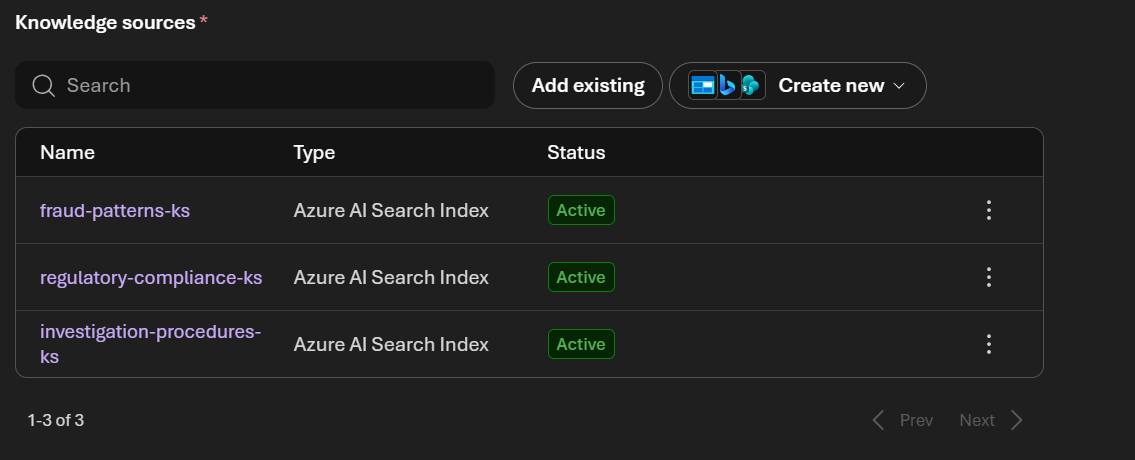


In [ ]:
from azure.search.documents.indexes.models import (
    KnowledgeBase,
    KnowledgeSourceReference,
    KnowledgeBaseAzureOpenAIModel,
)

knowledge_base_name = "fraud-investigation-kb"

# Delete existing KB if present
try:
    index_client.get_knowledge_base(knowledge_base_name)
    print(f"ðŸ—‘ï¸ Deleting existing knowledge base '{knowledge_base_name}'...")
    index_client.delete_knowledge_base(knowledge_base_name)
    time.sleep(2)
except ResourceNotFoundError:
    pass

# Configure the GPT model for the KB (used for agentic retrieval planning)
aoai_model_params = AzureOpenAIVectorizerParameters(
    resource_url=azure_openai_endpoint,
    deployment_name=model_deployment,
    model_name=model_deployment,
)

# References to all 3 knowledge sources
ks_references = [
    KnowledgeSourceReference(name=config["ks_name"])
    for config in knowledge_sources_config.values()
]

# Create the knowledge base
knowledge_base = KnowledgeBase(
    name=knowledge_base_name,
    description="Fraud investigation knowledge base with multi-source intelligent routing.",
    knowledge_sources=ks_references,
    models=[KnowledgeBaseAzureOpenAIModel(azure_open_ai_parameters=aoai_model_params)],
)

index_client.create_or_update_knowledge_base(knowledge_base=knowledge_base)

print("=" * 60)
print(f"âœ… Knowledge Base Created: {knowledge_base_name}")
print("=" * 60)
print(f"\nðŸ“Š Configuration:")
print(f"   â€¢ Name: {knowledge_base_name}")
print(f"   â€¢ Model: {model_deployment}")
print(f"   â€¢ Knowledge Sources: {len(ks_references)}")
for config in knowledge_sources_config.values():
    print(f"      - {config['ks_name']}")


---

## ðŸ” Step 8: Query Knowledge Base (Agentic Retrieval)

Query the knowledge base directly via the REST API. The KB handles:
- **Routing** â€” picks the right knowledge source(s) based on the query
- **Retrieval** â€” searches with vector + semantic ranking

No agent needed â€” just a REST call with the search API key.


In [7]:
import requests
import json

# KB retrieve endpoint
search_api_key = search_conn.credentials.get("key", "")
retrieve_url = f"{search_endpoint.rstrip('/')}/knowledgebases/{knowledge_base_name}/retrieve?api-version=2025-11-01-Preview"

test_questions = [
    "What are the key red flags for synthetic identity fraud?",
    "When must I file a Suspicious Activity Report and what should it contain?",
    "What's the proper procedure for freezing a suspicious account?",
]

print("=" * 70)
print("ðŸ” AGENTIC RETRIEVAL: Querying Knowledge Base Directly")
print("=" * 70)

for i, question in enumerate(test_questions, 1):
    print(f"\n{'â”€' * 70}")
    print(f"ðŸ“ Query {i}: {question}")
    print(f"{'â”€' * 70}")

    resp = requests.post(
        retrieve_url,
        headers={"api-key": search_api_key, "Content-Type": "application/json"},
        json={
            "messages": [
                {
                    "role": "user",
                    "content": [{"type": "text", "text": question}],
                }
            ]
        },
        timeout=60,
    )

    if resp.status_code == 200:
        result = resp.json()

        # Response is a list of message objects
        response_list = result.get("response", [])
        content = ""
        if isinstance(response_list, list) and response_list:
            msg = response_list[0]
            content_parts = msg.get("content", [])
            if isinstance(content_parts, list):
                content = " ".join(
                    p.get("text", "") for p in content_parts if isinstance(p, dict)
                )
            elif isinstance(content_parts, str):
                content = content_parts

        if content and content != "[]":
            print(f"\nðŸ¤– Answer (first 500 chars):")
            print(content[:500] + ("..." if len(content) > 500 else ""))

        # Show references (docKey = document ID from the index)
        references = result.get("references", [])
        if references:
            print(f"\nðŸ“š References: {len(references)} documents")
            for r in references[:5]:
                print(f"   â€¢ {r.get('docKey', '?')} (score: {r.get('rerankerScore', 0):.2f})")

        # Show activity summary (which knowledge sources were searched)
        activity = result.get("activity", [])
        searches = [a for a in activity if a.get("type") == "searchIndex"]
        total_hits = sum(a.get("count", 0) for a in searches)
        ks_used = set(a.get("knowledgeSourceName", "?") for a in searches)
        print(f"\nðŸ“Š Routing: {len(searches)} searches across {', '.join(ks_used)} â†’ {total_hits} hits")

        if not content or content == "[]":
            print("âš ï¸ No answer generated")
    else:
        print(f"âš ï¸ HTTP {resp.status_code}: {resp.text[:300]}")

print(f"\n{'=' * 70}")
print("âœ… Agentic retrieval queries complete!")
print("=" * 70)

ðŸ” AGENTIC RETRIEVAL: Querying Knowledge Base Directly

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ðŸ“ Query 1: What are the key red flags for synthetic identity fraud?
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
âš ï¸ HTTP 404: {"error":{"code":"","message":"No Knowledge Base with the name 'fraud-investigation-kb' was found in service 'alliander-search-uvrqgq'."}}

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ðŸ“ Query 2: When must I file a Suspicious Activity Report and what should it co

---

## ðŸ¤– Step 9: Create Agent with Knowledge Base (MCP Tool)

Connect the Knowledge Base to a Foundry Agent via [MCP (Model Context Protocol)](https://learn.microsoft.com/en-us/azure/foundry/agents/how-to/foundry-iq-connect?tabs=foundry%2Cpython). This is the official pattern for Foundry IQ:

1. **Create a project connection** â€” `RemoteTool` connection with `ProjectManagedIdentity` auth pointing to the KB's MCP endpoint
2. **Create an agent** â€” `PromptAgentDefinition` with an `MCPTool` that references the connection

The agent uses the KB's `knowledge_base_retrieve` tool, which handles query planning, retrieval across all 3 knowledge sources, and answer synthesis automatically.

> **âš ï¸ Prerequisites â€” RBAC & AAD Auth**
>
> The agent authenticates to the search service via the project's managed identity. You need:
>
> 1. **Enable AAD authentication** on your search service (default is API key only):
>    ```bash
>    az search service update \
>      --name <search-service-name> \
>      --resource-group <resource-group> \
>      --auth-options aadOrApiKey \
>      --aad-auth-failure-mode http401WithBearerChallenge
>    ```
> 2. **Assign RBAC roles** to the Foundry project's managed identity on the search service:
>    - `Search Index Data Reader` â€” read index data
>    - `Search Service Contributor` â€” access KB MCP endpoint
> 3. **Assign `Cognitive Services OpenAI User`** to the search service's managed identity on the AI Services account (needed for KB query planning with GPT).

In [14]:
import requests
from azure.ai.projects.models import PromptAgentDefinition, MCPTool

agent_name = "FraudInvestigationAgent"
project_connection_name = f"{knowledge_base_name}-connection"

# MCP endpoint for the knowledge base
mcp_endpoint = f"{search_endpoint.rstrip('/')}/knowledgebases/{knowledge_base_name}/mcp?api-version=2025-11-01-preview"

# â”€â”€ Step 9a: Create a RemoteTool project connection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# This lets the agent's managed identity authenticate to the KB MCP endpoint
bearer_token_provider = get_bearer_token_provider(credential, "https://management.azure.com/.default")
headers = {"Authorization": f"Bearer {bearer_token_provider()}"}

conn_response = requests.put(
    f"https://management.azure.com{project_resource_id}/connections/{project_connection_name}?api-version=2025-10-01-preview",
    headers=headers,
    json={
        "name": project_connection_name,
        "type": "Microsoft.MachineLearningServices/workspaces/connections",
        "properties": {
            "authType": "ProjectManagedIdentity",
            "category": "RemoteTool",
            "target": mcp_endpoint,
            "isSharedToAll": True,
            "audience": "https://search.azure.com/",
            "metadata": {"ApiType": "Azure"},
        },
    },
)
conn_response.raise_for_status()
print(f"âœ… Project connection '{project_connection_name}' created")
print(f"   â€¢ Target: {mcp_endpoint[:80]}...")

# â”€â”€ Step 9b: Create the agent with MCPTool â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
mcp_kb_tool = MCPTool(
    server_label="knowledge-base",
    server_url=mcp_endpoint,
    require_approval="never",
    allowed_tools=["knowledge_base_retrieve"],
    project_connection_id=project_connection_name,
)

instructions = """You are a helpful Fraud Investigation Analyst.

Use the knowledge base tool to answer all user questions. You must never answer from your own knowledge.
If the knowledge base doesn't contain the answer, respond with "I don't know".

When you use information from the knowledge base, include citations to the retrieved sources.
Every answer must provide annotations using the MCP knowledge base tool."""

agent = project_client.agents.create_version(
    agent_name=agent_name,
    definition=PromptAgentDefinition(
        model=model_deployment,
        instructions=instructions,
        tools=[mcp_kb_tool],
    ),
)

print(f"\n{'=' * 60}")
print(f"âœ… Fraud Investigation Agent Created")
print("=" * 60)
print(f"\nðŸ“Š Agent Configuration:")
print(f"   â€¢ Name: {agent.name}")
print(f"   â€¢ Version: {agent.version}")
print(f"   â€¢ Model: {model_deployment}")
print(f"   â€¢ Tool: MCPTool â†’ knowledge_base_retrieve")
print(f"   â€¢ Connection: {project_connection_name}")
print(f"   â€¢ Knowledge Base: {knowledge_base_name} (3 knowledge sources)")

✅ Project connection 'fraud-investigation-kb-connection' created
   • Target: https://alliander-search-uvrqgq.search.windows.net/knowledgebases/fraud-investig...

✅ Fraud Investigation Agent Created

📊 Agent Configuration:
   • Name: FraudInvestigationAgent
   • Version: 3
   • Model: gpt-4o
   • Tool: MCPTool → knowledge_base_retrieve
   • Connection: fraud-investigation-kb-connection
   • Knowledge Base: fraud-investigation-kb (3 knowledge sources)


---

## ðŸ§ª Step 10: Test the Fraud Investigation Agent

Test the agent with queries that target different search indexes. The agent decides which index(es) to query based on the question.


In [16]:
import time

print(f"ðŸ¤– Using Agent: {agent.name} (Version: {agent.version})")

# Create a conversation
conversation = openai_client.conversations.create()
print(f"âœ… Conversation created: {conversation.id}\n")

# Test questions targeting different knowledge sources
test_queries = [
    {
        "question": "What are the key red flags for synthetic identity fraud?",
        "expected_source": "Fraud Patterns",
        "emoji": "ðŸ”"
    },
    {
        "question": "When must I file a Suspicious Activity Report and what should it contain?",
        "expected_source": "Regulatory Compliance",
        "emoji": "ðŸ“‹"
    },
    {
        "question": "What's the proper procedure for freezing a suspicious account?",
        "expected_source": "Investigation Procedures",
        "emoji": "ðŸ“"
    },
    {
        "question": "I found a potential money mule network - what are the patterns, regulations, and investigation steps?",
        "expected_source": "ALL THREE SOURCES",
        "emoji": "ðŸŒŸ"
    }
]

print("=" * 70)
print("ðŸ§ª TESTING AGENT WITH KNOWLEDGE BASE (MCP)")
print("=" * 70)

for i, test in enumerate(test_queries, 1):
    print(f"\n{'â”€' * 70}")
    print(f"{test['emoji']} TEST {i}: Expected source â†’ {test['expected_source']}")
    print(f"{'â”€' * 70}")
    print(f"\nðŸ’¬ Question: {test['question']}")
    print(f"\nâ³ Agent querying knowledge base...")

    response = openai_client.responses.create(
        conversation=conversation.id,
        input=test["question"],
        extra_body={
            "agent_reference": {
                "name": agent.name,
                "type": "agent_reference",
            }
        },
    )

    output = response.output_text
    print(f"\nðŸ¤– Response:")
    print(f"{'â”€' * 70}")
    if len(output) > 1500:
        output = output[:1500] + "\n\n... [truncated for display]"
    print(output)

    time.sleep(2)

print(f"\n{'=' * 70}")
print("âœ… All tests complete!")
print("=" * 70)

ðŸ¤– Using Agent: FraudInvestigationAgent (Version: 3)
âœ… Conversation created: conv_e75d76c7c795b04600LnczMQrP2N0fQVAKmT6N2FaRrLQyd16D

ðŸ§ª TESTING AGENT WITH KNOWLEDGE BASE (MCP)

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ðŸ” TEST 1: Expected source â†’ Fraud Patterns
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

ðŸ’¬ Question: What are the key red flags for synthetic identity fraud?

â³ Agent querying knowledge base...


ðŸ¤– Using Agent: FraudInvestigationAgent (Version: 3)
âœ… Conversation created: conv_e75d76c7c795b04600LnczMQrP2N0fQVAKmT6N2FaRrLQyd16D

ðŸ§ª TESTING AGENT WITH KNOWLEDGE BASE (MCP)

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ðŸ” TEST 1: Expected source â†’ Fraud Patterns
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

ðŸ’¬ Question: What are the key red flags for synthetic identity fraud?

â³ Agent querying knowledge base...


BadRequestError: Error code: 400 - {'error': {'message': 'The remote MCP server at https://alliander-search-uvrqgq.search.windows.net:443/knowledgebases/fraud-investigation-kb/mcp returned HTTP 404 (Not Found) while enumerating tools. This means the specified URL endpoint does not exist on the remote server. Please verify: (1) the server URL is correct and the server is running, (2) the URL path points to a valid MCP endpoint, and (3) the server has been deployed and configured to handle requests at this URL.', 'type': 'invalid_request_error', 'param': None, 'code': 'tool_user_error'}}

---

## ðŸ§¹ Step 11: Cleanup Resources

Delete the agent, knowledge base, knowledge sources, and search indexes. Uncomment the code below to run cleanup.


In [19]:
# ============================================================================
# CLEANUP - Delete all resources (resilient to stale kernel state)
# ============================================================================

import requests
import time
from azure.identity import get_bearer_token_provider

# Delete ALL versions of the agent (kernel `agent.version` may be stale)
try:
    for v in project_client.agents.list_versions(agent_name=agent.name):
        try:
            project_client.agents.delete_version(agent_name=agent.name, agent_version=v.version)
            print(f"✅ Deleted agent: {agent.name} v{v.version}")
        except Exception as e:
            print(f"⚠️  Could not delete {agent.name} v{v.version}: {e}")
except Exception as e:
    print(f"⚠️  Could not list agent versions: {e}")

# Delete the project connection (Azure Resource Manager)
try:
    bearer_tp = get_bearer_token_provider(credential, "https://management.azure.com/.default")
    conn_del = requests.delete(
        f"https://management.azure.com{project_resource_id}/connections/{project_connection_name}?api-version=2025-10-01-preview",
        headers={"Authorization": f"Bearer {bearer_tp()}"},
    )
    print(f"✅ Deleted connection: {project_connection_name} ({conn_del.status_code})")
except Exception as e:
    print(f"⚠️  Could not delete connection: {e}")

# Delete knowledge base (must be deleted before knowledge sources)
try:
    index_client.delete_knowledge_base(knowledge_base_name)
    print(f"✅ Deleted knowledge base: {knowledge_base_name}")
except Exception as e:
    print(f"⚠️  Could not delete KB: {e}")

# Delete knowledge sources (must be deleted before indexes)
for config in knowledge_sources_config.values():
    try:
        index_client.delete_knowledge_source(config['ks_name'])
        print(f"✅ Deleted knowledge source: {config['ks_name']}")
    except Exception as e:
        print(f"⚠️  Could not delete KS {config['ks_name']}: {e}")

# Delete indexes
time.sleep(2)
for config in knowledge_sources_config.values():
    try:
        index_client.delete_index(config['index_name'])
        print(f"✅ Deleted index: {config['index_name']}")
    except Exception as e:
        print(f"⚠️  Could not delete index {config['index_name']}: {e}")

print("\n🧹 Cleanup complete")


✅ Deleted agent: FraudInvestigationAgent v2
✅ Deleted agent: FraudInvestigationAgent v1
⚠️  Could not list agent versions: (bad_request) The resource identified by 'after' Id Azure.AI.Agents.Services.Clients.Contracts.EntityId`1[Microsoft.Azure.Cosmos.PartitionKey] does not exist. [Request ID: 1f150b82eb160a57bfa514d305a56d41]
Code: bad_request
Message: The resource identified by 'after' Id Azure.AI.Agents.Services.Clients.Contracts.EntityId`1[Microsoft.Azure.Cosmos.PartitionKey] does not exist. [Request ID: 1f150b82eb160a57bfa514d305a56d41]
✅ Deleted connection: fraud-investigation-kb-connection (204)
✅ Deleted knowledge base: fraud-investigation-kb
✅ Deleted knowledge source: fraud-patterns-ks
✅ Deleted knowledge source: regulatory-compliance-ks
✅ Deleted knowledge source: investigation-procedures-ks
✅ Deleted index: fraud-patterns-index
✅ Deleted index: regulatory-compliance-index
✅ Deleted index: investigation-procedures-index

🧹 Cleanup complete


---

## ðŸ“š Summary

### What You Built

| Component | Description |
|-----------|-------------|
| **3 Search Indexes** | Vector + semantic search indexes for fraud investigation |
| **3 Knowledge Sources** | Abstraction layer mapping index fields to the retrieval engine |
| **1 Knowledge Base** | Agentic retrieval with intelligent routing across sources |
| **1 Project Connection** | `RemoteTool` connection with `ProjectManagedIdentity` for MCP auth |
| **1 Prompt Agent** | Fraud analyst using `MCPTool` â†’ `knowledge_base_retrieve` |

### Two Query Approaches

| | Direct REST Query (Step 8) | Agent with MCP Tool (Steps 9-10) |
|---|---|---|
| **How it works** | POST to KB `/retrieve` endpoint | Agent calls `knowledge_base_retrieve` via MCP |
| **Query planning** | KB handles routing + retrieval | KB handles routing + retrieval (same) |
| **Answer generation** | Raw retrieval results returned | Agent synthesizes answer with citations |
| **Best for** | Programmatic access, testing | Conversational AI, multi-turn sessions |

### References

- [Connect Agents to Foundry IQ Knowledge Bases](https://learn.microsoft.com/en-us/azure/foundry/agents/how-to/foundry-iq-connect?tabs=foundry%2Cpython)
- [Create a knowledge base in Azure AI Search](https://learn.microsoft.com/en-us/azure/search/agentic-retrieval-how-to-create-knowledge-base)
- [Foundry IQ: Unlocking ubiquitous knowledge for agents](https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/foundry-iq-unlocking-ubiquitous-knowledge-for-agents/4470812)